# 04 · Function walkthrough: the 12 functions, one at a time

**Purpose.** Run each function of the default/prepay model on its own, with a tiny example you can check by hand, to see exactly what it does before it is used inside the full pool projection (notebook 03).

**How to use.** Run the cells top to bottom (Shift+Enter). Each section has:
- **What it does**: the formula and the idea
- **Example**: a small call with printed output
- **Try it**: a number to change, so you can watch the result move

Order: conversions → amortization → prepayment → credit → projection.

| # | Function | File |
|---|---|---|
| 1 | `calculate_smm` | `src/prepayment.py` |
| 2 | `smm_to_cpr` | `src/prepayment.py` |
| 3 | `cdr_to_mdr` | `src/credit_model.py` |
| 4 | `scheduled_principal` | `src/collateral_projection.py` |
| 5 | `refi_incentive` | `src/prepayment.py` |
| 6 | `calculate_cpr` | `src/prepayment.py` |
| 7 | `mark_to_market_ltv` | `src/credit_model.py` |
| 8 | `calculate_credit_event_rate` | `src/credit_model.py` |
| 9 | `calculate_loss_severity` | `src/credit_model.py` |
| 10 | `modification_loss` | `src/credit_model.py` |
| — | `calculate_prepayment`, `calculate_credit_events` | one-line steps used inside #11 |
| 11 | `project_collateral` | `src/collateral_projection.py` |
| 12 | `run_scenarios` | `src/collateral_projection.py` |

Model parameters are **fitted on Freddie Mac loan-level history** (notebook 05). The `PARAMS` dicts are printed below.

**What you will see (results in brief).** Each function's example confirms the expected economics: monthly rates compound correctly; a 30-year loan amortizes to exactly $0; lower rates speed up prepayment along an S-curve that burns out over time; falling home prices raise LTV, defaults and severity; and the full STACR pool runs from $19.44bn to $7.34bn by the 2031 call in the base case. Losses are 0.17–0.26% of the cut-off balance, around the size of Freddie Mac's retained first-loss piece. A **Result** cell after each section explains its output.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.4f}".format)

from src import prepayment as pp, credit_model as cm, collateral_projection as cp
print("prepayment PARAMS:", pp.PARAMS)
print("credit PARAMS:   ", cm.PARAMS)

prepayment PARAMS: {'turnover': 0.055, 'refi_max': 0.414, 'midpoint': 0.714, 'slope': 2.736, 'burnout': 0.0076, 'ramp_months': 6.2}
credit PARAMS:    {'base_cdr': 0.004, 'b_ltv_low': 0.021, 'b_ltv_high': 0.04, 'b_fico': 0.0091, 'b_dti': 0.0227, 'investor_mult': 1.22, 'dq30_extra_mdr': 0.0228, 'dq30_months': 12, 'liq_lag': 19, 'costs': 0.1, 'reo_discount': 0.48, 'mi_coverage': 0.185, 'mod_share': 0.57, 'mod_rate_cut': 0.57}


**Q&A · Setup**

**Q: Why does the first cell search upward for a folder containing `src/`?**
A: The model code lives in `src/` at the repo root. Jupyter may start in the repo root or in `notebooks/`, so the cell walks up the folder tree until it finds `src/` and adds that folder to `sys.path`. Then `from src import ...` works wherever the notebook is opened.

**Q: Why are FutureWarnings turned off? Doesn't that hide problems?**
A: pandas 2.2 running on Python 3.14 prints spurious "chained assignment" warnings from `clean.py`, which drown out the real output. Only *warnings* are hidden. Real errors still stop the cell, so nothing that would make a result wrong is suppressed.

**Q: Why print the `PARAMS` dicts?**
A: Every result below depends on them. Printing them at the top shows which version of the model you're running: these are the values fitted in notebook 05, not the earlier placeholders.

### Three toy loans used throughout
Small enough to check by hand: a good borrower, a weaker borrower with a higher coupon, and an investor loan that is 30 days delinquent.

In [2]:
toy = pd.DataFrame({
    "Loan ID": ["good", "weaker", "investor_dq30"],
    "Current Balance": [300_000.0, 500_000.0, 400_000.0],
    "Gross Coupon": [6.75, 7.25, 7.50],
    "Credit Score": [780, 680, 720],
    "Original LTV": [75, 80, 80],
    "HPI Adjusted LTV": [65.0, 78.0, 75.0],
    "Current Debt to Income": [30, 45, 40],
    "Age": [18, 18, 18],
    "Months to Maturity": [342, 342, 342],
    "Occupancy": ["Owner Occupied", "Owner Occupied", "Investment Property"],
    "dq_bucket": [0, 0, 1],
})
toy

,Loan ID,Current Balance,Gross Coupon,Credit Score,Original LTV,HPI Adjusted LTV,Current Debt to Income,Age,Months to Maturity,Occupancy,dq_bucket
0,good,"300,000.0000",6.7500,780,75,65.0000,30,18,342,Owner Occupied,0
1,weaker,"500,000.0000",7.2500,680,80,78.0000,45,18,342,Owner Occupied,0
2,investor_dq30,"400,000.0000",7.5000,720,80,75.0000,40,18,342,Investment Property,1


**Q&A · Toy loans**

**Q: Why use three made-up loans instead of real ones?**
A: With three loans you can check every number by hand and see *why* each one behaves differently. The loans differ on purpose: `good` has high FICO, low DTI and LTV 65; `weaker` has FICO 680, DTI 45 and LTV 78; `investor_dq30` is an investment property already 30 days late. Real STACR loans come in at section 11.

**Q: Which columns do the functions actually use?**
A: Prepayment uses `Gross Coupon` and `Age`. Defaults use `HPI Adjusted LTV`, `Credit Score`, `Current Debt to Income`, `Occupancy` and `dq_bucket`. Severity uses `HPI Adjusted LTV`, `Gross Coupon` and `Original LTV` (for MI). The projection also needs `Current Balance` and `Months to Maturity`. These are the same names as in the cleaned Bloomberg tape.

---
## 1 · `calculate_smm`: annual prepay rate → monthly

**What it does.** CPR is the share of the balance prepaid over a year, and SMM is the share prepaid each month. A balance survives a year only if it survives 12 months in a row:

$$1 - CPR = (1 - SMM)^{12} \quad\Rightarrow\quad SMM = 1 - (1 - CPR)^{1/12}$$

That is why SMM is a bit **more** than CPR/12: the monthly rate applies to a shrinking balance.

In [3]:
cprs = np.array([0.06, 0.10, 0.20, 0.40, 0.60])
pd.DataFrame({"CPR": cprs, "SMM": pp.calculate_smm(cprs), "naive CPR/12": cprs / 12})

,CPR,SMM,naive CPR/12
0,0.0600,0.0051,0.0050
1,0.1000,0.0087,0.0083
2,0.2000,0.0184,0.0167
3,0.4000,0.0417,0.0333
4,0.6000,0.0735,0.0500


**Result #1.** SMM is always a bit **above** CPR/12, and the gap widens with speed: 6% CPR → 0.51% vs 0.50%, 20% → 1.84% vs 1.67%, and 60% → **7.35% vs 5.00%**. Dividing by 12 would understate monthly prepayments by up to a third at high speeds. The monthly rate has to be larger because it applies to a balance that is already shrinking.

**Try it:** what SMM does 100% CPR give? Why does the formula break down there?

**Q&A · #1 `calculate_smm`**

**Q: What SMM does 100% CPR give, and why does the formula break down there? (Try it)**
A: SMM = 1 − (1 − 1)^(1/12) = **100%**: the whole balance prepays in the first month. That's the edge of the formula's range. Above 100% CPR, (1 − CPR) is negative and has no real 12th root, which is why the model caps CPR at 99%.

**Q: Why is SMM always above CPR/12?**
A: The monthly rate is applied to a balance that keeps shrinking. To remove the same 6% over a year from smaller and smaller balances, each month's rate has to be slightly above 0.5%.

---
## 2 · `smm_to_cpr`: monthly → annual (the inverse)

$$CPR = 1 - (1 - SMM)^{12}$$

Useful for reporting: the model works monthly, but the market quotes CPR.

In [4]:
smm = pp.calculate_smm(cprs)
print("SMM:        ", smm.round(5))
print("back to CPR:", pp.smm_to_cpr(smm).round(5))   # should equal the original CPRs
print("1% SMM is a CPR of", f"{pp.smm_to_cpr(0.01):.2%}")

SMM:         [0.00514 0.00874 0.01842 0.04168 0.07352]
back to CPR: [0.06 0.1  0.2  0.4  0.6 ]
1% SMM is a CPR of 11.36%


**Result #2.** The round trip returns exactly 6%, 10%, 20%, 40% and 60%, so the two functions are true inverses. Also, **1% SMM is 11.36% CPR**, not 12%. This is the function used to report the model's monthly prepayments as the CPRs the market quotes.

**Q&A · #2 `smm_to_cpr`**

**Q: When is `smm_to_cpr` used?**
A: The model works in monthly SMMs, but the market quotes prepayment as CPR. This function converts the projection back, for example to report "21% CPR in year 1" in notebooks 03 and 05.

**Q: Why is 1% SMM 11.36% CPR rather than 12%?**
A: Surviving 12 months at 99% a month leaves 0.99¹² = 88.64% of the balance, so 11.36% prepaid. The shrinking balance works in the opposite direction from #1.

---
## 3 · `cdr_to_mdr`: annual default rate → monthly

Same math as #1, applied to defaults: $MDR = 1 - (1 - CDR)^{1/12}$. The default model's base rate (0.40% a year, fitted) is set annually and converted here.

In [5]:
cdrs = np.array([0.002, 0.01, 0.05])
pd.DataFrame({"CDR": cdrs, "MDR": cm.cdr_to_mdr(cdrs)})

,CDR,MDR
0,0.0020,0.0002
1,0.0100,0.0008
2,0.0500,0.0043


**Result #3.** The fitted base default rate of 0.40% a year becomes a monthly rate of **0.033%**. For reference, 0.2% CDR is 0.017% a month, 1% CDR is 0.084%, and 5% CDR is 0.43%. At these low levels MDR ≈ CDR/12. The compounding gap only matters at high rates, the same math as #1.

**Q&A · #3 `cdr_to_mdr`**

**Q: Is a default the same as a loss?**
A: No. Here a "default" is a loan starting a spell that reaches 90+ days delinquent. In the Freddie data only 43% of those spells end in liquidation, and the loss is then the balance times severity. So 0.40% a year of defaults at the base covariates becomes roughly 0.17% a year of liquidations, and about 0.07–0.08% a year of losses at a 45% severity.

**Q: When does the exact conversion matter?**
A: Only at high rates. At 5% CDR, CDR/12 = 0.417% a month vs the exact 0.427%. At crisis rates (10%+) the gap becomes meaningful.

---
## 4 · `scheduled_principal`: contractual amortization

**What it does.** A 30-year fixed mortgage has a level payment. Each month:

$$\text{payment} = \frac{B\,r}{1-(1+r)^{-n}}, \qquad \text{interest} = B\,r, \qquad \text{principal} = \text{payment} - \text{interest}$$

with $r$ = coupon / 1200 and $n$ = months remaining. Hand check: $300k, 6.75%, 342 months → **$290.46**.

[290.4585561]
balance after last payment: 0.0


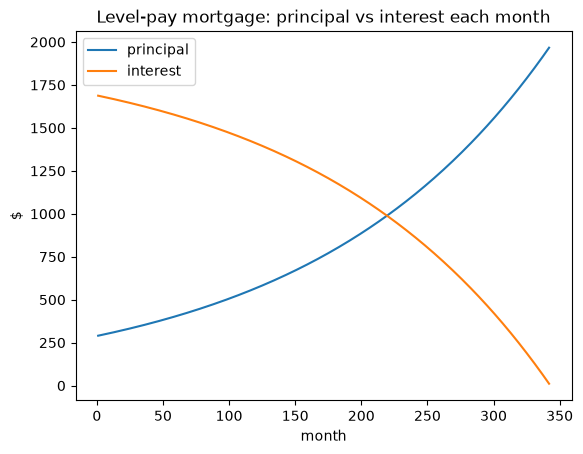

In [6]:
print(cp.scheduled_principal(np.array([300_000.0]), np.array([6.75]), np.array([342])))

# Amortize one loan to maturity: principal share grows over time
b, rows = 300_000.0, []
for m in range(342):
    p = cp.scheduled_principal(np.array([b]), np.array([6.75]), np.array([342 - m]))[0]
    rows.append((m + 1, p, b * 0.0675 / 12)); b -= p
amort = pd.DataFrame(rows, columns=["month", "principal", "interest"]).set_index("month")
amort.plot(title="Level-pay mortgage: principal vs interest each month"); plt.ylabel("$")
print("balance after last payment:", round(b, 6))

**Result #4.** Month-1 principal is **$290.46**, matching the hand calculation. The payment is $1,977.96, of which $1,687.50 is interest. The plot shows the level-pay structure: interest dominates early (85% of the first payment), the lines cross around month 220, and the last payment is almost all principal ($1,966.89 vs $11.06 of interest). The balance ends at exactly **$0.00**, so the amortization is correct.

For the pool this means **scheduled principal is small** for young loans, about 0.1% of the balance a month. Most of the pool's principal will come from prepayments (#6).

**Try it:** change the coupon to 3.0. Why does the principal share start much higher?

**Q&A · #4 `scheduled_principal`**

**Q: Why does the principal share start much higher at a 3% coupon? (Try it)**
A: Interest is balance × r. At 3% the month-1 interest on $300k is $750 instead of $1,687.50, and the payment is also lower, so a much bigger share of each payment goes to principal (about $556 at 3% vs $290 at 6.75%, for 342 months left). Low-coupon loans amortize faster.

**Q: How does the function handle the last month?**
A: When one month is left, it returns the whole remaining balance, so the loan ends at exactly $0.00 (shown by "balance after last payment: 0.0").

---
## 5 · `refi_incentive`: how far in the money each loan is

$$\text{incentive}_{t} = \text{loan coupon} - \text{market mortgage rate}_{t} \quad (\text{pp})$$

Positive means the borrower could lower their rate by refinancing. Output shape: (loans × months).

In [7]:
rates = np.array([7.00, 6.50, 6.25, 6.00, 5.50, 5.00])   # a falling-rate path, 6 months
pd.DataFrame(pp.refi_incentive(toy, rates), index=toy["Loan ID"],
             columns=[f"m{i+1} @ {r}%" for i, r in enumerate(rates)])

,m1 @ 7.0%,m2 @ 6.5%,m3 @ 6.25%,m4 @ 6.0%,m5 @ 5.5%,m6 @ 5.0%
Loan ID,,,,,,
good,-0.2500,0.2500,0.5000,0.7500,1.2500,1.7500
weaker,0.2500,0.7500,1.0000,1.2500,1.7500,2.2500
investor_dq30,0.5000,1.0000,1.2500,1.5000,2.0000,2.5000


**Result #5.** Incentive = coupon − market rate. At 7.00% only the `good` loan (6.75% coupon) is out of the money (**−0.25 pp**). As rates fall to 5.00%, every loan becomes deeply in the money (+1.75 to +2.50 pp). Higher-coupon loans always have more incentive at the same market rate, so in a rally they are the first to refinance.

**Q&A · #5 `refi_incentive`**

**Q: Why is incentive a matrix (loans × months)?**
A: Each loan has its own coupon, and the market rate changes every month along the scenario path. Incentive is computed for every loan in every month, and the S-curve then turns each cell into a CPR.

**Q: Why is the `good` loan out of the money at 7.00% but the others aren't?**
A: Its coupon is 6.75%, below 7.00%, so refinancing would raise its rate (−0.25 pp). The `weaker` (7.25%) and investor (7.50%) loans have higher coupons, so they're already in the money at 7.00%.

---
## 6 · `calculate_cpr`: the prepayment S-curve (fitted)

$$CPR = \underbrace{\min(1, \tfrac{age}{6.2})}_{\text{seasoning}} \times \Big[\underbrace{5.5\%}_{\text{turnover}} + \underbrace{41.4\%}_{\text{refi max}} \times \underbrace{\frac{1}{1+e^{-2.74(\text{inc}-0.71)}}}_{\text{S-curve}} \times \underbrace{e^{-0.0076\sum \text{past inc}^+}}_{\text{burnout}}\Big]$$

- **Turnover**: people move even with no rate benefit.
- **S-curve**: little refinancing out of the money, steep around +0.71 pp vs PMMS, saturating deep in the money.
- **Burnout**: loans that stayed in the money without refinancing are the less responsive ones.
- **Seasoning**: the fitted ramp is only about 6 months, so new loans reach full speed quickly.

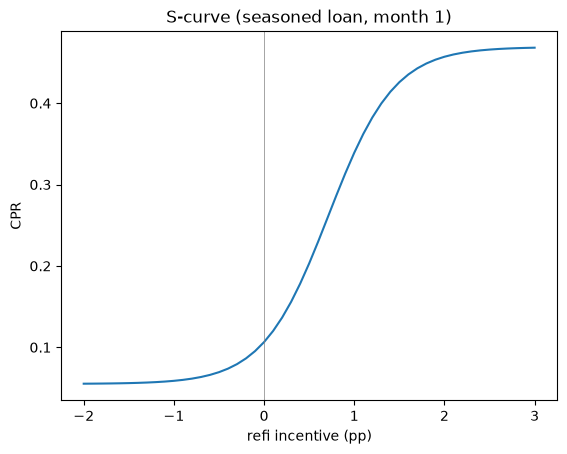

Text(0.5, 1.0, 'Burnout: same incentive, falling CPR over time')

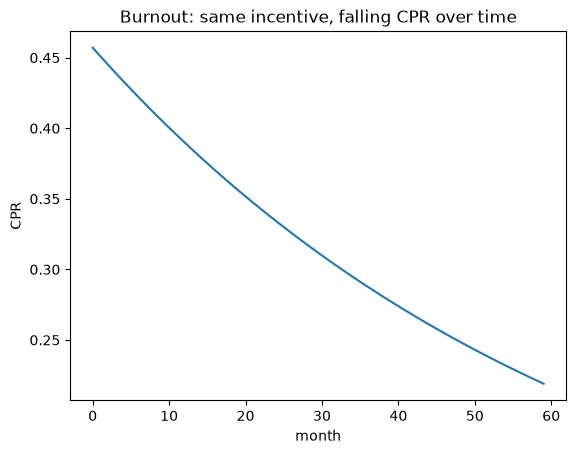

In [8]:
# (a) The S-curve: month-1 CPR vs incentive for one seasoned loan
one = toy.iloc[[0]].assign(Age=60)
grid = np.arange(-2, 3.01, 0.1)
s_curve = [pp.calculate_cpr(one, np.array([one["Gross Coupon"].iloc[0] - x]))[0, 0] for x in grid]
plt.plot(grid, s_curve); plt.axvline(0, color="grey", lw=0.5)
plt.xlabel("refi incentive (pp)"); plt.ylabel("CPR"); plt.title("S-curve (seasoned loan, month 1)")
plt.show()

# (b) Burnout: hold rates 2pp below the coupon for 5 years
path = np.full(60, 6.75 - 2.0)
plt.plot(pp.calculate_cpr(one, path)[0]); plt.xlabel("month"); plt.ylabel("CPR")
plt.title("Burnout: same incentive, falling CPR over time")

In [9]:
# (c) The three toy loans on the falling-rate path from #5
pd.DataFrame(pp.calculate_cpr(toy, rates), index=toy["Loan ID"],
             columns=[f"m{i+1} @ {r}%" for i, r in enumerate(rates)])

,m1 @ 7.0%,m2 @ 6.5%,m3 @ 6.25%,m4 @ 6.0%,m5 @ 5.5%,m6 @ 5.0%
Loan ID,,,,,,
good,0.0826,0.1458,0.2028,0.2710,0.3876,0.4379
weaker,0.1458,0.2718,0.3369,0.3863,0.4365,0.4477
investor_dq30,0.2031,0.3380,0.3876,0.4182,0.4443,0.4468


**Result #6 (fitted parameters).**
- **S-curve (first plot).** For a seasoned loan, CPR is about **5.5%** when 2 pp out of the money (turnover only), **10.6%** at zero incentive, **26%** at the +0.71 pp midpoint, **43%** at +1.5 pp, and it levels off near **47%**. The steep section between 0 and +1.5 pp is where speeds are most rate-sensitive.
- **Burnout (second plot).** At a constant +2 pp incentive, CPR falls from **46% in month 1 to 40% by month 12 and 22% by month 60**. The fitted burnout is gentler than the placeholder's.
- **Toy loans on the falling-rate path (table).** All three speed up as rates fall: `good` goes from **8.3% to 44% CPR**, and the investor loan starts fastest (20%) because its 7.50% coupon gives the most incentive. By month 6 they converge around **44–45%** near the top of the S-curve. With a fitted 6-month seasoning ramp, these 18-month-old loans are already at full speed.

**Try it:** set `pp.PARAMS['midpoint'] = 0.5` and rerun. Where does the steep part move? (Set it back to 0.714 afterwards.)

**Q&A · #6 `calculate_cpr`**

**Q: Where does the steep part move if `midpoint` is set to 0.5? (Try it)**
A: The S-curve shifts **left** by about 0.21 pp: borrowers reach half of the maximum refinancing speed at +0.5 pp instead of +0.71 pp. At any given positive incentive, CPR is higher, so the same rate path pays the pool down faster. (Set it back to 0.714 afterwards.)

**Q: What does each fitted parameter mean economically?**
A: `turnover` 5.5% is prepayment from moving and home sales. `refi_max` 41% is the extra speed available from refinancing. `midpoint` 0.71 pp is the rate saving where refinancing is half switched on. `slope` 2.74 sets how quickly speeds rise around it. `burnout` 0.0076 is how fast speeds fade after a loan has been in the money for a while. `ramp_months` 6.2 is how quickly new loans reach full speed.

**Q: Why does the investor loan start faster than `good`?**
A: Only because of its coupon. At 7.00% it has +0.50 pp of incentive vs −0.25 pp for `good`. Occupancy doesn't enter the prepayment model.

---
## 7 · `mark_to_market_ltv`: LTV along a house-price path

$$LTV_t = \frac{\text{HPI-adjusted LTV on the tape}}{HPI_t}, \qquad HPI_0 = 1$$

If prices fall 20%, a 65 LTV loan becomes 65 / 0.8 = 81.25. (Amortization is ignored, which is slightly conservative.)

In [10]:
hpi_down = np.linspace(1.0, 0.80, 13)       # 12 months, -20%
ltv = cm.mark_to_market_ltv(toy, hpi_down)
pd.DataFrame(ltv[:, [0, 5, 11]], index=toy["Loan ID"], columns=["month 1", "month 6", "month 12"])

,month 1,month 6,month 12
Loan ID,,,
good,66.1017,72.2222,81.2500
weaker,79.3220,86.6667,97.5000
investor_dq30,76.2712,83.3333,93.7500


**Result #7.** A 20% home-price decline over 12 months raises every loan's LTV by a factor of 1/0.8: `good` goes **65 → 81**, `investor_dq30` **75 → 94** and `weaker` **78 → 97.5**, close to being underwater. This is the channel through which house prices drive both defaults (#8) and severity (#9).

**Q&A · #7 `mark_to_market_ltv`**

**Q: Why is month 1 already above the starting LTV?**
A: The path falls linearly from 1.00 to 0.80 over 12 months, so in month 1 HPI is already 0.983, and 65 / 0.983 = 66.1.

**Q: Which toy loan is closest to being underwater, and why does it matter?**
A: `weaker`: LTV 78 becomes 97.5 at HPI 0.80, almost no equity left. Above 80 the fitted default effect steepens, and severity rises with LTV, so this loan's expected loss rises much faster than `good`'s.

---
## 8 · `calculate_credit_event_rate`: monthly default hazard per loan (fitted)

$$MDR = MDR_{base}\; e^{\,b_{ltv}(LTV_t-80)}\; e^{-0.0091(FICO-750)}\; e^{0.0227(DTI-38)} \times 1.22_{[\text{investor}]} \;+\; 2.28\%_{[\text{30 dq, first 12m}]}$$

with $b_{ltv}$ = 0.021 below 80 LTV and 0.040 above (losing equity raises default faster). The base rate is 0.40% a year at LTV 80, FICO 750, DTI 38 (post-2008 vintages). Here a "default" means a loan starting a spell that reaches 90+ days delinquent.

In [11]:
paths = {"HPI +10%": np.linspace(1, 1.10, 13), "flat": np.ones(13), "HPI -20%": hpi_down}
tbl = pd.DataFrame({name: cm.calculate_credit_event_rate(toy, h)[:, -1] * 12 * 100 for name, h in paths.items()},
                   index=toy["Loan ID"])
tbl.columns = [c + " (annualized %, month 12)" for c in tbl.columns]
tbl

,"HPI +10% (annualized %, month 12)","flat (annualized %, month 12)","HPI -20% (annualized %, month 12)"
Loan ID,,,
good,0.1640,0.1856,0.2674
weaker,0.7338,0.8517,1.7886
investor_dq30,27.8845,27.9652,28.5251


**Result #8** (annualized default-spell rates in month 12, fitted).
- **Borrower quality matters.** With flat prices, `weaker` (FICO 680, DTI 45, LTV 78) is at **0.85%** a year vs **0.19%** for `good` (FICO 780, DTI 30, LTV 65), about 4.6× higher.
- **Falling prices amplify it.** At HPI −20%, `weaker`'s LTV crosses 80 into the steeper part of the LTV term, and its rate roughly **doubles to 1.79%**. `good` only rises to 0.27% because it still has equity.
- **Delinquency dominates.** `investor_dq30` is at about **28%** in every scenario. In the Freddie data, 24.5% of loans 30 days late reach 90+ within a year, and the model carries that as an extra hazard for 12 months.

All three move the right way: higher HPI → fewer defaults, and lower HPI → more defaults.

**Q&A · #8 `calculate_credit_event_rate`**

**Q: How much does each borrower trait move the default rate?**
A: Relative to LTV 80 / FICO 750 / DTI 38: every FICO point lower adds about 0.9% (FICO 700 ≈ 1.6×), every DTI point adds about 2.3%, an investment property is 1.22×, each LTV point above 80 adds about 4% (below 80, each point lower cuts about 2.1%). These multiply together.

**Q: Why is the investor loan at about 28% a year whatever home prices do?**
A: It's 30 days late on the tape, so it carries the extra 2.28% a month hazard for 12 months (≈ 24% a year on its own). That swamps the LTV effect from prices.

**Q: Why use a Poisson GLM for these coefficients?**
A: Default spells are rare counts per loan-month. A Poisson model with a log link estimates exactly this multiplicative form, log(MDR) = constant + Σ coefficient × trait, which is the formula the function uses.

---
## 9 · `calculate_loss_severity`: actual loss when a loan is liquidated

STACR is an **actual-loss** deal: the loss is what is really lost on the sale, not a fixed %.

$$\text{loss} = \underbrace{B\,(1 + 19\cdot\tfrac{c}{1200} + 10\%)}_{\text{balance + 19 months missed interest + costs}} - \underbrace{\tfrac{B}{LTV}\cdot HPI \cdot (1-48\%)}_{\text{distressed sale proceeds}} - \underbrace{MI}_{\text{18.5\% of claim, only if orig LTV}>80}$$

All inputs are fitted on Freddie liquidations (notebook 05).

Severity = loss / B, floored at 0.

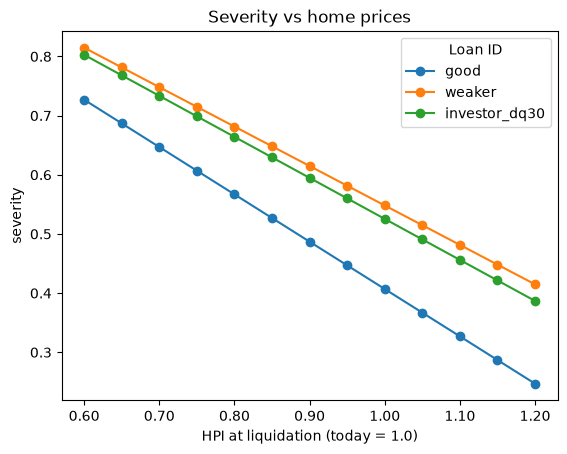

Loan ID,good,weaker,investor_dq30
0.80,0.5669,0.6815,0.6641
1.00,0.4069,0.5481,0.5254
1.10,0.3269,0.4815,0.4561


In [12]:
hpi_levels = np.arange(0.6, 1.21, 0.05)
sev = pd.DataFrame({f"{h:.2f}": cm.calculate_loss_severity(toy, h) for h in hpi_levels}, index=toy["Loan ID"]).T
sev.plot(marker="o"); plt.xlabel("HPI at liquidation (today = 1.0)"); plt.ylabel("severity")
plt.title("Severity vs home prices"); plt.show()
sev.loc[["0.80", "1.00", "1.10"]]

**Result #9 (fitted).** Severity is now **positive even with plenty of equity**, then rises as prices fall.
- `good` (LTV 65): **41% at today's prices**, 33% at HPI 1.10 and 57% at HPI 0.80. It would only reach zero above HPI 1.5.
- `weaker` (LTV 78): **55%** today, 68% at HPI 0.80.
- `investor_dq30` (LTV 75): 53% today, 66% at HPI 0.80.

Why so high? In the Freddie data, liquidated homes sell about **48% below** their HPI-indexed value, liquidation costs about 10% of UPB, and about 19 months of interest is lost before the sale. Liquidated loans at 50–70 LTV still lost a median 42–45% (notebook 05). Equity still helps, but it's no longer a full shield.

**Try it:** how high would home prices have to rise before the *good* loan (LTV 65) loses nothing at liquidation? What does that say about how much protection equity gives in an actual-loss deal like STACR?

**Q&A · #9 `calculate_loss_severity`**

**Q: How high would prices have to rise before the `good` loan loses nothing? (Try it)**
A: About **50%** (HPI ≈ 1.5). The claim is 1 + 19 × 6.75/1200 + 10% ≈ 1.21× the balance. Proceeds are (1/0.65) × HPI × 0.52, so they only cover the claim when HPI ≈ 1.21 × 0.65 / 0.52 ≈ 1.5. Even with 35% equity, a liquidation still loses money, so in an actual-loss deal equity lowers the *probability* of loss much more than its *size*.

**Q: Why is `weaker`'s severity higher than `good`'s at every price level?**
A: With LTV 78 the home is worth only 1.28× the loan (vs 1.54× at LTV 65), so sale proceeds cover less of the balance, and its higher coupon (7.25%) adds more missed interest. Its severity is 55% today vs 41% for `good`. Per 10% price drop, `good`'s severity actually rises slightly more (about 0.080× vs 0.067× the balance), because each percent of a relatively larger home value is more dollars per dollar of loan.

**Q: What does MI do in the formula?**
A: For loans with original LTV above 80 (none in STACR DNA1, all of CAS group 2), mortgage insurance pays 18.5% of the claim, lowering severity by about 0.2× the balance.

---
## 10 · `modification_loss`: cost of rate cuts

57% of default spells never liquidate (fitted: they cure, are modified, or pay off). Those that are modified get an average 0.88 pp rate cut, which spreads to an effective **0.57 pp** across all non-liquidated spells. Under STACR the lost interest is a loss (PPM p. 84-85):

$$\text{monthly mod loss} = \text{modified balance} \times \frac{0.57}{1200}$$

In [13]:
bal = np.array([100_000.0, 1_000_000.0, 50_000_000.0])
pd.DataFrame({"modified balance": bal, "monthly loss ($)": cm.modification_loss(bal),
              "annual loss ($)": cm.modification_loss(bal) * 12})

,modified balance,monthly loss ($),annual loss ($)
0,"100,000.0000",47.5000,570.0000
1,"1,000,000.0000",475.0000,"5,700.0000"
2,"50,000,000.0000","23,750.0000","285,000.0000"


**Result #10.** The fitted effective rate cut of 0.57 pp costs **$47.50 a month per $100k** of modified balance ($570 a year), or $475 a month per $1mm. Even $50mm of modified loans only costs **$285k a year**. Modification losses are small and steady compared with liquidation losses, but they hit the junior tranches' **interest** first (PPM p. 84-85).

**Q&A · #10 `modification_loss`**

**Q: Why is the loss linear in modified balance?**
A: The lost interest each month is the rate cut times the balance: $1mm × 0.57% / 12 = $475. Double the balance, double the loss.

**Q: Who absorbs it in STACR?**
A: Under PPM p. 84-85 modification losses are allocated from the bottom up, cutting each class's *interest* before its principal: B-3H, B-2H, B-1H, then M-2B and M-2A interest, and so on. With these small amounts, only the retained B tranches are affected.

---
## 11 · `project_collateral`: everything together for one scenario

Each month, in this order (so a dollar never leaves twice):
1. **Defaults** = MDR × performing balance → into a 19-month liquidation pipeline (57% never liquidate)
2. **Scheduled principal** on what is left
3. **Prepayments** = SMM × (balance after scheduled principal)
4. **Credit events** = defaults from 19 months ago leave the pool; **loss** = balance × severity at that month's HPI

$$\text{ending} = \text{beginning} - \text{scheduled} - \text{prepayments} - \text{credit events}$$

First on the toy loans (readable), then on the real STACR pool.

In [14]:
N = 24
toy_cf = cp.project_collateral(toy, np.linspace(1, 0.85, N + 1), np.full(N, 6.0), N)
toy_cf.round(0).head(15)

,month,beginning_balance,scheduled_principal,prepayments,defaults,losses,recoveries,ending_balance,modification_losses,distressed_balance
0,1,"1,200,000.0000","1,065.0000","45,951.0000",0.0000,0.0000,0.0000,"1,152,984.0000",0.0000,"9,729.0000"
1,2,"1,152,984.0000","1,027.0000","43,445.0000",0.0000,0.0000,0.0000,"1,108,511.0000",3.0000,"18,930.0000"
2,3,"1,108,511.0000",991.0000,"41,103.0000",0.0000,0.0000,0.0000,"1,066,417.0000",5.0000,"27,637.0000"
3,4,"1,066,417.0000",957.0000,"38,912.0000",0.0000,0.0000,0.0000,"1,026,549.0000",7.0000,"35,881.0000"
4,5,"1,026,549.0000",925.0000,"36,860.0000",0.0000,0.0000,0.0000,"988,763.0000",9.0000,"43,696.0000"
5,6,"988,763.0000",894.0000,"34,939.0000",0.0000,0.0000,0.0000,"952,931.0000",10.0000,"51,107.0000"
6,7,"952,931.0000",864.0000,"33,138.0000",0.0000,0.0000,0.0000,"918,929.0000",12.0000,"58,141.0000"
7,8,"918,929.0000",836.0000,"31,448.0000",0.0000,0.0000,0.0000,"886,645.0000",13.0000,"64,821.0000"
8,9,"886,645.0000",809.0000,"29,861.0000",0.0000,0.0000,0.0000,"855,975.0000",14.0000,"71,167.0000"
9,10,"855,975.0000",784.0000,"28,371.0000",0.0000,0.0000,0.0000,"826,820.0000",15.0000,"77,202.0000"


In [15]:
check = toy_cf.beginning_balance - toy_cf.scheduled_principal - toy_cf.prepayments - toy_cf.defaults - toy_cf.ending_balance
print("balance identity, max error ($):", check.abs().max())
print("first credit events in month:", toy_cf.loc[toy_cf.defaults > 0, "month"].min(), f"({cm.PARAMS['liq_lag']}-month liquidation lag)")

balance identity, max error ($): 2.3283064365386963e-10
first credit events in month: 20 (19-month liquidation lag)


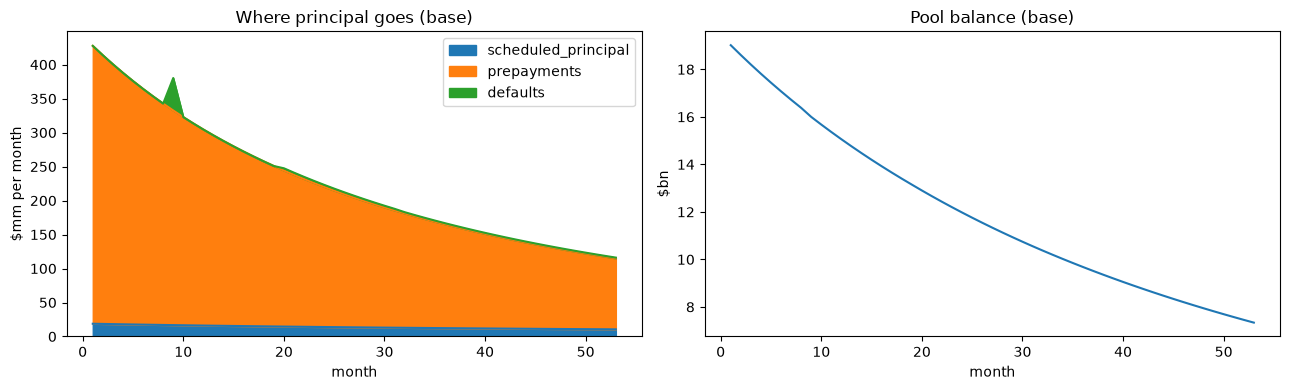

In [16]:
pool = pd.read_parquet(ROOT / "data" / "processed" / "stacr_dna1.parquet")
N = 53                                          # today -> Feb 2031 call
cf = cp.project_collateral(pool, np.linspace(1, 1.15, N + 1), np.full(N, 6.25), N)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
(cf.set_index("month")[["scheduled_principal", "prepayments", "defaults"]] / 1e6).plot.area(ax=ax[0])
ax[0].set_ylabel("$mm per month"); ax[0].set_title("Where principal goes (base)")
(cf.set_index("month")["ending_balance"] / 1e9).plot(ax=ax[1])
ax[1].set_ylabel("$bn"); ax[1].set_title("Pool balance (base)")
plt.tight_layout()

**Result #11 (fitted).**
- **Toy loans, 24 months, HPI −15%, rate 6%.** The $1.2mm pays down mostly through **prepayments** (about $46k in month 1 vs about $1k of scheduled principal). With the fitted 19-month liquidation lag, nothing liquidates until **month 20**. Over 24 months that gives about $19k of credit events, **$11.7k of losses** and $302 of modification losses, ending at $514k. The balance identity holds to within **$0.0000000002**.
- **Full STACR pool, base case (plots).** Month 1 has **$409mm of prepayments vs $19mm of scheduled principal**, and prepayments are about **93%** of all principal leaving the pool. The pool pays down **62%, from $19.44bn to $7.34bn**, by the Feb 2031 call. The month-9 spike in credit events is the $47.8mm of loans already seriously delinquent on the tape.

**Q&A · #11 `project_collateral`**

**Q: Why do the toy loans have no credit events until month 20?**
A: A default enters the pipeline and liquidates 19 months later (the fitted median). The first defaults happen in month 1, so the first credit events appear in month 20. The toy loans have no 60+ day delinquent loan at the start, so there's no early month-9 liquidation like in the real pool.

**Q: How do `calculate_prepayment` and `calculate_credit_events` fit in?**
A: They're the one-line steps inside the monthly loop: `calculate_credit_events(performing, MDR)` = defaults this month, and `calculate_prepayment(balance, scheduled, SMM)` = SMM × (balance − scheduled principal). Keeping them as separate functions makes the order of operations explicit.

**Q: What does the area chart show for the real pool?**
A: Almost all principal leaving the pool is prepayment (about 93%). Scheduled principal is a thin band, and credit events are barely visible except the month-9 liquidation of loans already seriously delinquent on the tape.

---
## 12 · `run_scenarios`: the same projection on several paths

Takes `{name: {"hpi": path, "rate": path}}` and returns `{name: table}`. These tables are what the waterfall consumes. The paths below are **placeholders** until Coco's scenarios are ready.

In [17]:
scenarios = {
    "good":     {"hpi": np.linspace(1.00, 1.25, N + 1), "rate": np.full(N, 5.00)},
    "base":     {"hpi": np.linspace(1.00, 1.15, N + 1), "rate": np.full(N, 6.25)},
    "moderate": {"hpi": np.linspace(1.00, 0.90, N + 1), "rate": np.full(N, 5.75)},
    "severe":   {"hpi": np.linspace(1.00, 0.75, N + 1), "rate": np.full(N, 5.25)},
}
results = cp.run_scenarios(pool, scenarios, N)
pd.DataFrame({name: {
    "end balance ($bn)": df.ending_balance.iloc[-1] / 1e9,
    "credit events ($mm)": df.defaults.sum() / 1e6,
    "losses ($mm)": df.losses.sum() / 1e6,
    "loss / cut-off (%)": df.losses.sum() / cp.CUTOFF_BALANCE * 100,
    "avg severity (%)": df.losses.sum() / df.defaults.sum() * 100,
} for name, df in results.items()})

,good,base,moderate,severe
end balance ($bn),3.2205,7.3395,4.7607,3.4560
credit events ($mm),96.2283,111.4537,109.1678,108.6650
losses ($mm),38.9723,47.5681,55.1383,60.0656
loss / cut-off (%),0.1711,0.2088,0.2420,0.2637
avg severity (%),40.4999,42.6797,50.5079,55.2760


**Result #12** (fitted parameters, placeholder scenarios).

| | good | base | moderate | severe |
|---|---|---|---|---|
| End balance | $3.22bn | $7.34bn | $4.76bn | $3.46bn |
| Credit events | $96mm | $111mm | $109mm | $109mm |
| Losses | $39.0mm | $47.6mm | $55.1mm | $60.1mm |
| Loss / cut-off | 0.171% | 0.209% | 0.242% | 0.264% |
| Avg severity | 40.5% | 42.7% | 50.5% | 55.3% |

- **Losses are 3–15× the placeholder results** (13× in the base case), driven by the fitted severity (40–55% instead of 3–18%).
- **Stress raises losses mostly through severity**, since credit events barely change ($96–111mm). The 19-month lag means only defaults in the first ~34 months liquidate before the 2031 call, and the placeholder stress paths cut rates, so loans prepay away before prices bottom out (see the Try it below).
- **Base and moderate stay inside B-3H (0–0.25%)**, and **severe just reaches B-2H** (about $3mm). The offered A-1, M-1 and M-2 notes take **no write-downs**, since M-2B attaches at 1.90%.

**Try it:** add a scenario `"severe_no_refi"` with HPI to 0.75 but rates at 7.5%. Do losses go up or down vs `severe`, and why? (Hint: who is still in the pool when home prices bottom out?)

**Q&A · #12 `run_scenarios`**

**Q: Do losses go up or down with a "severe_no_refi" path (HPI to 0.75, rates 7.5%)? (Try it)**
A: **Up.** With rates at 7.5% the pool is out of the money, so prepayments drop to about turnover speed. More loans are still in the pool when prices bottom out, so more of them default and liquidate at high severity. The placeholder severe path (5.25%) lets many borrowers refinance away first, which understates the loss. A realistic stress combines falling prices with rates that don't help borrowers who are underwater.

**Q: Why do credit events barely change across scenarios ($96–111mm)?**
A: Three reasons: about $48mm is the tape's already-delinquent loans, the same in every scenario; the 19-month lag means only defaults in the first ~34 months liquidate before the 2031 call; and faster prepayment in the stress paths shrinks the balance that can default.

**Q: Why does severity rise from 40% to 55% across scenarios?**
A: Severity depends on HPI at liquidation. Rising prices (good, base) raise sale proceeds, while falling prices (moderate, severe) cut them, on top of fixed costs and missed interest.

---
## Summary of results (fitted parameters)

| # | Function | What the output showed |
|---|---|---|
| 1–2 | `calculate_smm`, `smm_to_cpr` | 6% CPR = 0.51% SMM, 60% CPR = 7.35% SMM (not 5%); 1% SMM = 11.36% CPR; round trip exact |
| 3 | `cdr_to_mdr` | fitted 0.40% a year = 0.033% a month; compounding only matters at high rates |
| 4 | `scheduled_principal` | $290.46 in month 1 (85% of the payment is interest); balance hits $0.00 at maturity |
| 5 | `refi_incentive` | from −0.25 to +2.50 pp across the falling-rate path |
| 6 | `calculate_cpr` | fitted S-curve from ~5.5% (turnover) to ~47%; burnout takes CPR from 46% to 22% over 5 years at constant incentive |
| 7 | `mark_to_market_ltv` | HPI −20% lifts LTV 65 → 81 and 78 → 97.5 |
| 8 | `calculate_credit_event_rate` | weaker borrower ~4.6× the good one; HPI −20% doubles it; 30-day dq loan ~28% a year |
| 9 | `calculate_loss_severity` | 41–55% at today's prices, 57–68% at HPI 0.80; equity helps but doesn't eliminate loss |
| 10 | `modification_loss` | effective 0.57 pp cut = $475 a month per $1mm |
| 11 | `project_collateral` | identity holds; first new credit events in month 20; ~93% of principal is prepayment; pool −62% by Feb 2031 |
| 12 | `run_scenarios` | losses 0.171% / 0.209% / 0.242% / 0.264% of cut-off (good / base / moderate / severe); severe just reaches B-2H; offered notes untouched |

**Main takeaway.** Calibrated on Freddie history, base-case credit losses on this pool are about 13× the placeholder estimate, because distressed sales lose far more than equity alone suggests. They still stay below the 1.90% subordination that protects the offered notes. The offered notes' main exposure remains **prepayment speed (timing and WAL)**.

**Limits to fix next.** (1) The scenario paths are placeholders until Coco's `scenarios.py` is ready, and today's PMMS (7.28%) is well above the 6.25% base path. (2) Underwater borrowers can still refinance in the model, which understates stress losses. (3) The fitted severity is steeper in LTV than the data (notebook 05).